#Microsoft Stock forecasting with LSTM

In [2]:
import yfinance as yf

msft = yf.Ticker("MSFT")
data = msft.history(period="15y")
data.to_csv("microsoft_stock_data.csv")

print("Download complete! First 5 rows:")
print(data.head())

Download complete! First 5 rows:
                                Open       High        Low      Close  \
Date                                                                    
2011-03-28 00:00:00-04:00  19.646912  19.692851  19.432525  19.455496   
2011-03-29 00:00:00-04:00  19.401894  19.539713  19.371266  19.516743   
2011-03-30 00:00:00-04:00  19.600969  19.692847  19.524402  19.608625   
2011-03-31 00:00:00-04:00  19.600968  19.662221  19.401895  19.440178   
2011-04-01 00:00:00-04:00  19.547369  19.547369  19.378922  19.509085   

                             Volume  Dividends  Stock Splits  
Date                                                          
2011-03-28 00:00:00-04:00  48973200        0.0           0.0  
2011-03-29 00:00:00-04:00  40763500        0.0           0.0  
2011-03-30 00:00:00-04:00  41999300        0.0           0.0  
2011-03-31 00:00:00-04:00  63233700        0.0           0.0  
2011-04-01 00:00:00-04:00  63114200        0.0           0.0  


In [3]:
data.describe()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
count,3771.000000,3771.000000,3771.000000,3771.000000,3.771000e+03,3771.000000,3771.0
mean,163.985411,165.500966,162.379022,164.005758,3.304400e+07,0.007568,0.0
std,148.458404,149.718721,147.054870,148.425867,1.847153e+07,0.064998,0.0
min,18.303679,18.504065,18.226611,18.272856,5.855900e+06,0.000000,0.0
25%,37.835861,38.259529,37.587757,37.992966,2.152455e+07,0.000000,0.0
50%,98.784652,99.886220,97.612324,98.653969,2.814230e+07,0.000000,0.0
75%,273.750973,276.804618,270.130461,273.696671,3.889575e+07,0.000000,0.0
max,552.023241,552.242002,538.530652,539.825256,3.193179e+08,0.910000,0.0


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3771 entries, 2011-03-28 00:00:00-04:00 to 2026-03-25 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          3771 non-null   float64
 1   High          3771 non-null   float64
 2   Low           3771 non-null   float64
 3   Close         3771 non-null   float64
 4   Volume        3771 non-null   int64  
 5   Dividends     3771 non-null   float64
 6   Stock Splits  3771 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 235.7 KB


In [5]:
data = data.reset_index() # to reset the index

In [6]:
data.head()

,Date,Open,High,Low,Close,Volume,Dividends,Stock Splits
0,2011-03-28 00:00:00-04:00,19.646912,19.692851,19.432525,19.455496,48973200,0.0,0.0
1,2011-03-29 00:00:00-04:00,19.401894,19.539713,19.371266,19.516743,40763500,0.0,0.0
2,2011-03-30 00:00:00-04:00,19.600969,19.692847,19.524402,19.608625,41999300,0.0,0.0
3,2011-03-31 00:00:00-04:00,19.600968,19.662221,19.401895,19.440178,63233700,0.0,0.0
4,2011-04-01 00:00:00-04:00,19.547369,19.547369,19.378922,19.509085,63114200,0.0,0.0


In [7]:
df = data[['Close']]
df

,Close
0,19.455496
1,19.516743
2,19.608625
3,19.440178
4,19.509085
...,...
3766,389.019989
3767,381.869995
3768,383.000000
3769,372.739990


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3771 entries, 0 to 3770
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   3771 non-null   float64
dtypes: float64(1)
memory usage: 29.6 KB


In [9]:
# Keras and Tensorflow > 2

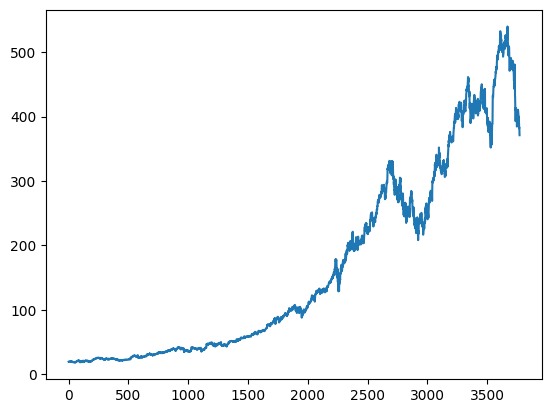

In [10]:
import matplotlib.pyplot as plt
plt.plot(df["Close"])

In [11]:
# LSTM Are Sensitive to the scale of data . so we apply MinMax Scaler

In [12]:
import numpy as np

In [13]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))
df= scaler.fit_transform(np.array(df).reshape(-1,1))

In [14]:
df

array([[0.00226754],
       [0.00238497],
       [0.00256114],
       ...,
       [0.69931064],
       [0.67963858],
       [0.67637912]])

In [15]:
# Splitting data into train , test Split
# i am going to use training data = 65 , test = 35
training_size =  int(len(df)*0.65)
test_size = len(df) - training_size
train_data, test_data = df[0:training_size,:], df[training_size:len(df),:1]

In [18]:
import numpy
# convert an array of value into a dataset matrix
def create_dataset(dataset, time_step =1):
  dataX, dataY = [],[]
  for i in range(len(dataset)-time_step-1):
    a = dataset[i:(i+time_step),0]
    dataX.append(a)
    dataY.append(dataset[i+time_step,0])
  return numpy.array(dataX), numpy.array(dataY)

In [19]:
# Reshaping it now : X = t, t+1, t+2, t+3 and Y = t+4
time_step = 100
X_train, y_train = create_dataset(train_data, time_step)
X_test, y_test = create_dataset(test_data, time_step)


In [20]:
print(X_train)

[[0.00226754 0.00238497 0.00256114 ... 0.00265981 0.00265981 0.0025111 ]
 [0.00238497 0.00256114 0.00223817 ... 0.00265981 0.0025111  0.00164866]
 [0.00256114 0.00223817 0.00237029 ... 0.0025111  0.00164866 0.00072669]
 ...
 [0.33261453 0.33727176 0.3339295  ... 0.35139222 0.3564217  0.35814716]
 [0.33727176 0.3339295  0.33765528 ... 0.3564217  0.35814716 0.35801873]
 [0.3339295  0.33765528 0.33736309 ... 0.35814716 0.35801873 0.36747194]]


In [22]:
print(X_train.shape),print(X_test.shape),print(y_train.shape),print(y_test.shape)

(2350, 100)
(1219, 100)
(2350,)
(1219,)


(None, None, None, None)

In [25]:
# Reshape Input to be [samples , time steps , features] which is required for LSTM
X_train = X_train.reshape(X_train.shape[0],X_train.shape[1],1)
X_test = X_test.reshape(X_test.shape[0],X_test.shape[1],1)

In [24]:
# Create the STacked LSTM Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import LSTM

In [26]:
model = Sequential()
model.add(LSTM(50, return_sequences=True, input_shape=(100,1)))
model.add(LSTM(50, return_sequences=True))
model.add(LSTM(50))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 100, 50)        │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 100, 50)        │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,851 (198.64 KB)

 Trainable params: 50,851 (198.64 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=100, batch_size=64 ,verbose = 1)

Epoch 1/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 14s 247ms/step - loss: 0.0032 - val_loss: 9.9708e-04
Epoch 2/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 252ms/step - loss: 6.8728e-05 - val_loss: 0.0013
Epoch 3/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 192ms/step - loss: 4.9468e-05 - val_loss: 0.0028
Epoch 4/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 198ms/step - loss: 4.7240e-05 - val_loss: 0.0027
Epoch 5/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - loss: 5.0260e-05 - val_loss: 0.0045
Epoch 6/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 194ms/step - loss: 4.9505e-05 - val_loss: 0.0032
Epoch 7/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 220ms/step - loss: 4.8668e-05 - val_loss: 0.0035
Epoch 8/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 9s 242ms/step - loss: 4.9999e-05 - val_loss: 0.0038
Epoch 9/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 7s 196ms/step - loss: 4.6053e-05 - val_loss: 0.0038
Epoch 10/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 8s 226ms/step - loss: 5.0744e-05 - val_loss: 0.0049
Epoch 11/100
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 225ms/step - loss: 4.7443e-05 - val_loss: 0

In [29]:
# Lets do the predection and check performance metrics
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

74/74 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step


In [30]:
# Transform back to the normal form
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

In [31]:
# Calculate RMSE performace metrics
import math
from sklearn.metrics import mean_squared_error
math.sqrt(mean_squared_error(y_train, train_predict))

86.91023909313269

In [33]:
# Test Data RMSE :
math.sqrt(mean_squared_error(y_test, test_predict))

347.3310836330568

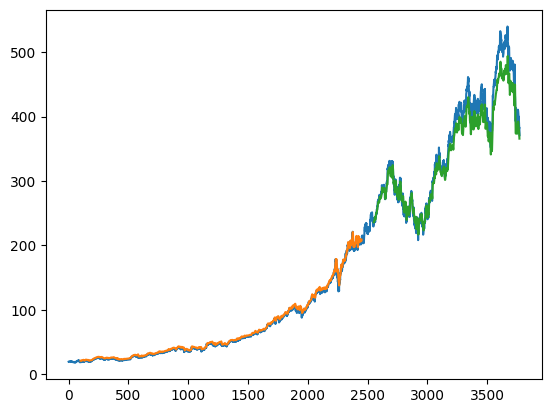

In [35]:
### Plotting
look_back = 100
trainPredictPlot = numpy.empty_like(df)
trainPredictPlot[:,:] = np.nan
trainPredictPlot[look_back:len(train_predict)+look_back,:] = train_predict

# shift test predections for plotting
testPredictPlot = numpy.empty_like(df)
testPredictPlot[:,:] = numpy.nan
testPredictPlot[len(train_predict)+(look_back*2)+1:len(df)-1,:] = test_predict

# plot baseline and predections
plt.plot(scaler.inverse_transform(df))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [36]:
len(test_data)

1320

In [38]:
x_input = test_data[1220:].reshape(1,-1)
x_input.shape

(1, 100)

In [39]:
temp_input = list(x_input)
temp_input = temp_input[0].tolist()

In [40]:
import numpy

In [41]:
lst_output = []
n_steps = 100
i = 0
while (i<30):

  if(len(temp_input)>100):
    #print temp input
    x_input = np.array(temp_input[1:])
    print("{} day input {}".format(i,x_input))
    x_input = x_input.reshape(1,-1)
    x_input = x_input.reshape((1,n_steps,1))
    # print (x_input)
    yhat = model.predict(x_input, verbose=0)
    print("{} day output {}".format(i,yhat))
    temp_input.extend(yhat[0].tolist())
    temp_input = temp_input[1:]
    # print temp input
    lst_output.extend(yhat.tolist())
    i = i+1

  else :
    x_input = x_input.reshape((1,n_steps,1))
    yhat = model.predict(x_input, verbose=0)
    print(yhat[0])
    temp_input.extend(yhat[0].tolist())
    print(len(temp_input))
    lst_output.extend(yhat.tolist())
    i = i+1

print(lst_output)


[0.6499326]
101
1 day input [0.95367751 0.95218824 0.94703289 0.93334232 0.91413363 0.91359899
 0.93112737 0.93624462 0.94094181 0.92595289 0.93910872 0.93397239
 0.90781352 0.89507765 0.88019464 0.86812371 0.87172015 0.87743991
 0.89371945 0.90617305 0.89609156 0.90232793 0.87885557 0.88480494
 0.88924309 0.90427916 0.90619213 0.88044332 0.88983612 0.88038598
 0.87328877 0.87629218 0.87577563 0.89081176 0.89452295 0.89260998
 0.89630203 0.89854015 0.89794718 0.89678026 0.89750723 0.89012306
 0.86969238 0.86952018 0.88034771 0.88983612 0.87958248 0.88182072
 0.87780339 0.8653499  0.8437523  0.83854897 0.84467048 0.83445512
 0.81454093 0.82798926 0.85632059 0.8646038  0.88430758 0.88631621
 0.79424419 0.78810348 0.77486563 0.75160368 0.75730442 0.71804995
 0.73233992 0.75617577 0.75554441 0.73851884 0.73367899 0.73268427
 0.72415232 0.72939391 0.7289529  0.72659459 0.70212915 0.71081476
 0.73305606 0.73520349 0.71798564 0.72912546 0.73944082 0.7418759
 0.75238296 0.74908511 0.74994794 0

In [46]:
day_new = np.arange(1,101)
day_pred =np.arange(101,131)


In [47]:
import matplotlib.pyplot as plt


In [48]:
len(df)

3771

In [49]:
df1 = df.tolist()
df1.extend(lst_output)


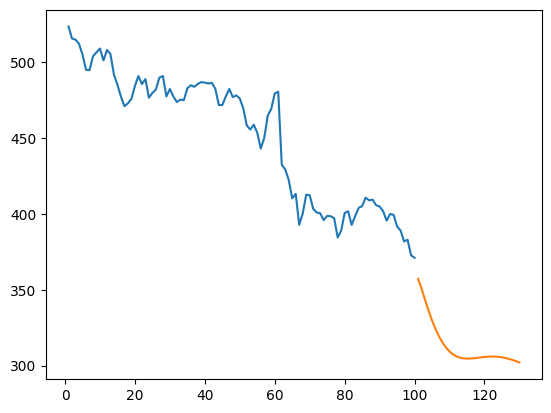

In [55]:
plt.plot(day_new, scaler.inverse_transform(df[-100:]))
plt.plot(day_pred, scaler.inverse_transform(lst_output))


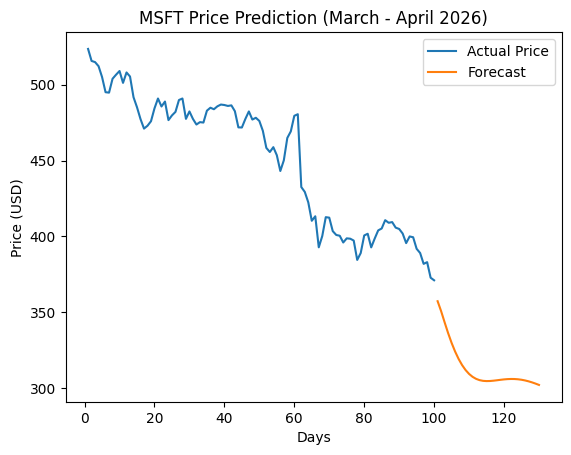

In [54]:
# 1. Prepare the X-axis for the last 100 days of known data
# We use indices 0 to 100
day_new = np.arange(1, 101)

# 2. Prepare the X-axis for the 30 days of prediction
# We start at 101 and go to 130
day_pred = np.arange(101, 131)

# 3. Plot the last 100 days of actual data
# df[-100:] gives us exactly the last 100 rows to match day_new
plt.plot(day_new, scaler.inverse_transform(df[-100:]), label="Actual Price")

# 4. Plot the 30-day forecast (including April 22nd)
plt.plot(day_pred, scaler.inverse_transform(lst_output), label="Forecast")

plt.title("MSFT Price Prediction (March - April 2026)")
plt.xlabel("Days")
plt.ylabel("Price (USD)")
plt.legend()
plt.show()

In [52]:
# lst_output contains your 30-day predictions
# We want the 28th day (index 27) for April 22nd

# 1. Extract the specific prediction
april_22_scaled = lst_output[27]

# 2. Reshape and Inverse Transform to get the USD price
# Note: your scaler was fitted on a 2D array, so we reshape to [[value]]
april_22_price = scaler.inverse_transform(np.array(april_22_scaled).reshape(-1, 1))

print(f"The predicted Microsoft stock price for April 22, 2026 is: ${april_22_price[0][0]:.2f}")

The predicted Microsoft stock price for April 22, 2026 is: $303.74


In [53]:
import pandas as pd

# Create a list of dates starting the day after your last data point
last_date = pd.to_datetime("2026-03-25")
prediction_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=30)

# Convert all predictions back to real prices
all_preds_real = scaler.inverse_transform(lst_output)

# Combine into a simple table
prediction_df = pd.DataFrame({
    'Date': prediction_dates,
    'Predicted_Price': all_preds_real.flatten()
})

# Look at April 22nd specifically
print(prediction_df[prediction_df['Date'] == '2026-04-22'])

         Date  Predicted_Price
27 2026-04-22       303.740453
